# QA3 — Target-language validity and legitimate variation (QA3.1 and QA3.2 aligned)

This notebook implements the QA3 metrics described in the thesis text through the canonical shared metric core. QA3.1 reports whole-text target-language probability, valid- and wrong-language indicators, exact English-copy detection, and window-level English code-switch detection. QA3.2 reports descriptive expansion ratio and aligned-reference advantage for alternative lexicalisations of the same RDF entry.


In [1]:

from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import hashlib
import importlib.util
import json
import os
import sys
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)


def find_repo_root() -> Path:
    override = Path("/home/vramon/notebooks/WebNLG_MT_eval")
    if override:
        root = Path(override).expanduser().resolve()
        if not (root / "WebNLG_CA_BT").exists():
            raise FileNotFoundError(
                f"WebNLG_CA_BT was not found under {root}"
            )
        return root

    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "WebNLG_CA_BT").exists():
            return candidate.resolve()

    mounted = Path("/mnt/data/RDF-to-text-MT-Evaluation-main")
    if mounted.exists():
        return mounted.resolve()

    raise FileNotFoundError(
        "Repository root not found. Set WEBNLG_REPO_ROOT."
    )


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "WebNLG_CA_BT"
CORE_PATH = (
    REPO_ROOT
    / "audit"
    / "QA_evaluation"
    / "audit_notebooks"
    / "aligned"
    / "audit_metric_core.py"
)
if not CORE_PATH.exists():
    raise FileNotFoundError(
        f"Shared metric core not found: {CORE_PATH}\n"
        "Copy audit_metric_core.py from the supplied package into "
        "audit/QA_evaluation/audit_notebooks/aligned/."
    )

spec = importlib.util.spec_from_file_location(
    "audit_metric_core",
    CORE_PATH,
)
core = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = core
spec.loader.exec_module(core)

if core.CORE_COMPATIBILITY != "audit-text-aligned-2.7":
    raise RuntimeError(
        "QA3 requires audit_metric_core.py compatibility "
        "'audit-text-aligned-2.7', but found "
        f"{core.CORE_COMPATIBILITY!r}."
    )

# Fail early if the QA3 implementations drift from Tables qa31 and qa32.
core.assert_qa31_metric_contract()
core.assert_qa32_metric_contract()

CORE_SHA256 = hashlib.sha256(
    CORE_PATH.read_bytes()
).hexdigest()

print("Repository root:", REPO_ROOT)
print("Metric core:", CORE_PATH)
print("Metric compatibility:", core.CORE_COMPATIBILITY)
print("Metric core SHA-256:", CORE_SHA256)

RESULTS_NAME = os.getenv(
    "QA3_RESULTS_NAME",
    "QA3_stress_aligned",
)
RESULTS_DIR = (
    REPO_ROOT
    / "QA_evaluation"
    / "results"
    / RESULTS_NAME
)
CACHE_DIR = (
    REPO_ROOT
    / "QA_evaluation"
    / "cache"
    / "QA3_stress_aligned"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

LANGUAGE_TRAINING_MAX = int(
    os.getenv("QA3_LANG_TRAIN_MAX", "6000")
)
MAX_ROWS_PER_LANGUAGE = (
    int(os.getenv("QA3_MAX_ROWS"))
    if os.getenv("QA3_MAX_ROWS")
    else None
)
FORCE_RECOMPUTE = (
    os.getenv("QA3_FORCE", "0") == "1"
)
SEMANTIC_BACKEND = os.getenv(
    "QA3_SEMANTIC_BACKEND", "sentence_transformer"
)
SEMANTIC_MODEL = os.getenv(
    "QA3_MODEL_NAME",
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)
SEMANTIC_BATCH_SIZE = int(os.getenv("QA3_BATCH_SIZE", "128"))
RANDOM_SEED = 42

print("Results directory:", RESULTS_DIR)
print(
    "Language training cap:",
    LANGUAGE_TRAINING_MAX,
)
print(
    "Rows per language:",
    MAX_ROWS_PER_LANGUAGE or "all",
)


Repository root: /home/vramon/notebooks/WebNLG_MT_eval
Metric core: /home/vramon/notebooks/WebNLG_MT_eval/audit/QA_evaluation/audit_notebooks/aligned/audit_metric_core.py
Metric compatibility: audit-text-aligned-2.7
Metric core SHA-256: d41a631b7be3fba492dfd90317ca7a96d9a24ed93dd52478b7243ed36746004c
Results directory: /home/vramon/notebooks/WebNLG_MT_eval/QA_evaluation/results/QA3_stress_aligned
Language training cap: 6000
Rows per language: all


## 1. Parse aligned source and target records

In [2]:

TARGET_LANGUAGES = {
    "es": {
        "label": "Spanish",
        "triple_set": "spanishtripleset",
        "triple_tag": "striple",
    },
    "ca": {
        "label": "Catalan",
        "triple_set": "catalantripleset",
        "triple_tag": "ctriple",
    },
}


def list_corpus_xml_files(root: Path):
    usable, ignored = [], []
    for path in root.rglob("*.xml"):
        relative = path.relative_to(root)
        if (
            any(part.startswith(".") for part in relative.parts)
            or path.name.endswith("-checkpoint.xml")
        ):
            ignored.append(path)
        else:
            usable.append(path)
    return sorted(usable), sorted(ignored)


def node_texts(entry, xpath: str):
    return [
        (node.text or "").strip()
        for node in entry.findall(xpath)
    ]


def lexicalisation_pairs(entry):
    result = defaultdict(list)
    for node in entry.findall("lex"):
        language = (node.get("lang") or "").strip()
        lid = (node.get("lid") or "").strip()
        text = (node.text or "").strip()
        if language:
            result[language].append((lid, text))
    return result


def build_clean_manifest(data_root: Path):
    rows = []
    mapping_rows = []
    entry_rows = []
    parse_errors = []
    xml_files, ignored_files = list_corpus_xml_files(data_root)

    for xml_path in xml_files:
        relative = xml_path.relative_to(data_root)
        split = relative.parts[0] if relative.parts else "unknown"
        triple_bucket = (
            relative.parts[1]
            if len(relative.parts) > 1
            else "unknown"
        )
        try:
            root = ET.parse(xml_path).getroot()
        except ET.ParseError as exc:
            parse_errors.append({
                "xml_path": relative.as_posix(),
                "error": str(exc),
            })
            continue

        for entry in root.findall(".//entry"):
            eid = (entry.get("eid") or "").strip()
            category = (entry.get("category") or "").strip()
            size_raw = (entry.get("size") or "").strip()
            try:
                declared_size = int(size_raw)
            except (TypeError, ValueError):
                declared_size = len(
                    node_texts(
                        entry,
                        ".//modifiedtripleset/mtriple",
                    )
                )

            source_triples = node_texts(
                entry,
                ".//modifiedtripleset/mtriple",
            )
            lexicalisations = lexicalisation_pairs(entry)
            english_pairs = lexicalisations.get("en", [])
            english_by_lid = defaultdict(list)
            for lid, text in english_pairs:
                english_by_lid[lid].append(text)

            record_key = f"{relative.as_posix()}::{eid}"
            entry_row = {
                "record_key": record_key,
                "xml_path": relative.as_posix(),
                "split": split,
                "triple_bucket": triple_bucket,
                "category": category,
                "eid": eid,
                "declared_size": declared_size,
                "source_triple_count": len(source_triples),
                "english_lexicalisations": len(english_pairs),
                "english_lids_unique": (
                    len(english_pairs)
                    == len(set(lid for lid, _ in english_pairs))
                ),
            }

            for language, config in TARGET_LANGUAGES.items():
                target_triples = node_texts(
                    entry,
                    f".//{config['triple_set']}/"
                    f"{config['triple_tag']}",
                )
                target_pairs = lexicalisations.get(language, [])
                target_by_lid = defaultdict(list)
                for lid, text in target_pairs:
                    target_by_lid[lid].append(text)

                entry_row.update({
                    f"{language}_target_triple_count": (
                        len(target_triples)
                    ),
                    f"{language}_target_lexicalisations": (
                        len(target_pairs)
                    ),
                    f"{language}_target_lids_unique": (
                        len(target_pairs)
                        == len(set(lid for lid, _ in target_pairs))
                    ),
                    f"{language}_lid_set_equal": (
                        set(english_by_lid)
                        == set(target_by_lid)
                    ),
                })

                all_lids = sorted(
                    set(english_by_lid)
                    | set(target_by_lid)
                )
                for lid in all_lids:
                    source_texts = english_by_lid.get(lid, [])
                    target_texts = target_by_lid.get(lid, [])
                    source_lid = lid if source_texts else ""
                    target_lid = lid if target_texts else ""
                    source_text = (
                        source_texts[0] if source_texts else ""
                    )
                    target_text = (
                        target_texts[0] if target_texts else ""
                    )
                    digest = hashlib.sha1(
                        (
                            f"{record_key}|{lid}|{language}"
                        ).encode("utf-8")
                    ).hexdigest()[:12]
                    rows.append({
                        "variant_id": (
                            f"original__{language}__{digest}"
                        ),
                        "base_pair_key": (
                            f"{record_key}::{lid}"
                        ),
                        "record_key": record_key,
                        "language": language,
                        "language_label": config["label"],
                        "qa_track": "CLEAN",
                        "corruption_type": "clean",
                        "severity": "clean",
                        "declared_size": declared_size,
                        "source_lid": source_lid,
                        "variant_lid": target_lid,
                        "source_triples": source_triples,
                        "clean_target_triples": target_triples,
                        "variant_target_triples": target_triples,
                        "source_text": source_text,
                        "clean_target_text": target_text,
                        "variant_target_text": target_text,
                        "xml_duplicate_target_lex": (
                            len(target_texts) > 1
                        ),
                        "xml_path": relative.as_posix(),
                        "split": split,
                        "triple_bucket": triple_bucket,
                        "category": category,
                        "eid": eid,
                        "is_benign": False,
                        "consistency_group_id": "",
                        "perturbation_pair_id": "",
                        "removed_token_fraction": np.nan,
                        "alternative_reference_lid": "",
                        "alternative_source_text": "",
                    })

                if (
                    len(source_triples)
                    == len(target_triples)
                    == declared_size
                ):
                    for triple_index, (
                        source_triple,
                        target_triple,
                    ) in enumerate(
                        zip(source_triples, target_triples)
                    ):
                        source = core.split_triple(source_triple)
                        target = core.split_triple(target_triple)
                        for role, position in (
                            ("subject", 0),
                            ("predicate", 1),
                            ("object", 2),
                        ):
                            mapping_rows.append({
                                "record_key": record_key,
                                "xml_path": relative.as_posix(),
                                "split": split,
                                "category": category,
                                "language": language,
                                "language_label": config["label"],
                                "triple_index": triple_index,
                                "role": role,
                                "component_type": (
                                    "predicate"
                                    if role == "predicate"
                                    else "entity_or_value"
                                ),
                                "source_raw": source[position],
                                "target_raw": target[position],
                                "source_normalized": (
                                    core.normalize_label(
                                        source[position]
                                    )
                                ),
                                "target_normalized": (
                                    core.normalize_label(
                                        target[position]
                                    )
                                ),
                            })
            entry_rows.append(entry_row)

    manifest = pd.DataFrame(rows)
    aligned = manifest[
        manifest["source_lid"].ne("")
        & manifest["variant_lid"].ne("")
        & manifest["source_text"].map(
            lambda value: bool(core.normalize_space(value))
        )
        & manifest["variant_target_text"].map(
            lambda value: bool(core.normalize_space(value))
        )
        & manifest["source_triples"].map(bool)
        & manifest["variant_target_triples"].map(bool)
    ].copy()

    return {
        "manifest": manifest.reset_index(drop=True),
        "aligned": aligned.reset_index(drop=True),
        "mappings": pd.DataFrame(mapping_rows),
        "entries": pd.DataFrame(entry_rows),
        "ignored_xml": pd.DataFrame({
            "xml_path": [
                path.relative_to(data_root).as_posix()
                for path in ignored_files
            ]
        }),
        "parse_errors": pd.DataFrame(parse_errors),
    }


In [3]:
parsed = build_clean_manifest(DATA_ROOT)
data = parsed["aligned"].copy()

if MAX_ROWS_PER_LANGUAGE is not None:
    sampled_groups = []
    for language, group in data.groupby(
        "language",
        sort=True,
    ):
        sampled_groups.append(
            group.sample(
                min(MAX_ROWS_PER_LANGUAGE, len(group)),
                random_state=RANDOM_SEED,
            )
        )
    data = pd.concat(
        sampled_groups,
        ignore_index=True,
    )

print("Aligned lexicalisations:", f"{len(data):,}")
display(
    data.groupby(
        ["language", "language_label"],
        as_index=False,
    ).agg(
        lexicalisations=("variant_id", "size"),
        records=("record_key", "nunique"),
    )
)


Aligned lexicalisations: 90,062


,language,language_label,lexicalisations,records
0,ca,Catalan,45031,16653
1,es,Spanish,45031,16653


## 2. QA3.1 — Target-language validity and source-language leakage

All QA3.1 indicators are calculated by the shared `audit_metric_core.py`. Whole-text language identification uses a confidence threshold of 0.70. English code switching is assessed with overlapping 10-token windows, a stride of 8, and a minimum retained window length of 6 tokens; the complete text is flagged when at least 25% of eligible windows have English probability of at least 0.70.


In [4]:
language_model, detector_metadata = (
    core.train_language_detector(
        REPO_ROOT,
        CACHE_DIR,
        LANGUAGE_TRAINING_MAX,
        FORCE_RECOMPUTE,
    )
)

qa31_metrics = core.qa31_compute_metrics(
    target_texts=data["variant_target_text"],
    source_texts=data["source_text"],
    expected_languages=data["language"],
    model=language_model,
)

for column in qa31_metrics.columns:
    data[column] = qa31_metrics[column].to_numpy()

# Dataset-level checks complement the synthetic QA3.1 contract.
if not data["target_language_probability"].between(
    0.0,
    1.0,
    inclusive="both",
).all():
    raise AssertionError(
        "Target-language probabilities must lie in [0, 1]."
    )

expected_valid = (
    data["predicted_language"].eq(data["language"])
    & data["target_language_probability"].ge(
        core.QA31_LANGUAGE_CONFIDENCE
    )
)
if not data["valid_target_language"].eq(expected_valid).all():
    raise AssertionError(
        "V_l(e) does not match the QA3.1 decision rule."
    )

expected_wrong = (
    data["predicted_language"].ne(data["language"])
    & data["language_confidence"].ge(
        core.QA31_LANGUAGE_CONFIDENCE
    )
)
if not data["wrong_language_detected"].eq(expected_wrong).all():
    raise AssertionError(
        "W_l(e) does not match the QA3.1 decision rule."
    )

expected_copy = (
    data["variant_target_text"].map(core.normalize_space)
    == data["source_text"].map(core.normalize_space)
)
if not data["full_english_copy_detected"].eq(
    expected_copy
).all():
    raise AssertionError(
        "C_l(e) must use whitespace-normalised exact equality."
    )


## 3. QA3.2 — Descriptive length variation and aligned-reference advantage

Expansion ratio compares each target lexicalisation with its aligned English lexicalisation and has no correctness threshold. Aligned-reference advantage is calculated only when the RDF entry contains another non-empty English lexicalisation with a different LID; the implementation selects one such comparison deterministically and evaluates whether the target is closer to its aligned English reference.


In [5]:
# QA3.1 hard language diagnostics contain no RDF-structure or predicate checks.
data["hard_language_flag"] = data[
    [
        "wrong_language_detected",
        "full_english_copy_detected",
        "code_switch_detected",
    ]
].any(axis=1)

# Select one different English lexicalisation b from the same RDF entry
# for each aligned target/source lexicalisation a.
comparison_references = core.qa32_select_comparison_references(
    data,
    record_column="record_key",
    source_lid_column="source_lid",
    source_text_column="source_text",
)
data["comparison_source_lid"] = comparison_references[
    "comparison_source_lid"
]
data["comparison_source_text"] = comparison_references[
    "comparison_source_text"
]

if SEMANTIC_BACKEND != "sentence_transformer":
    raise ValueError(
        "QA3.2 aligned-reference advantage requires the "
        "sentence_transformer backend used for multilingual "
        "semantic similarity."
    )

semantic_scorer = core.SemanticScorer(
    SEMANTIC_BACKEND,
    SEMANTIC_MODEL,
    SEMANTIC_BATCH_SIZE,
)

qa32_metrics = core.qa32_compute_metrics(
    aligned_source_texts=data["source_text"],
    target_texts=data["variant_target_text"],
    comparison_source_texts=data["comparison_source_text"],
    scorer=semantic_scorer,
    target_lids=data["variant_lid"],
    aligned_source_lids=data["source_lid"],
    comparison_source_lids=data["comparison_source_lid"],
    target_record_keys=data["record_key"],
    aligned_source_record_keys=data["record_key"],
    comparison_source_record_keys=data["record_key"],
)
for column in qa32_metrics.columns:
    data[column] = qa32_metrics[column].to_numpy()

# Dataset-level checks complement the synthetic QA3.2 contract.
if not data["expansion_ratio"].ge(0.0).all():
    raise AssertionError("QA3.2 expansion ratios must be non-negative.")

eligible = data["aligned_reference_eligible"]
if data.loc[
    ~eligible,
    "aligned_reference_advantage",
].notna().any():
    raise AssertionError(
        "Ineligible QA3.2 comparisons must not receive an advantage."
    )

advantages = data.loc[
    eligible,
    "aligned_reference_advantage",
].dropna()
if not advantages.between(-2.0, 2.0, inclusive="both").all():
    raise AssertionError(
        "QA3.2 aligned-reference advantage must lie in [-2, 2]."
    )


Batches:   0%|          | 0/1018 [00:00<?, ?it/s]

Batches:   0%|          | 0/921 [00:00<?, ?it/s]

## 4. Summaries

In [6]:
language_summary = (
    data.groupby(["language", "language_label"], as_index=False)
    .agg(
        variants=("variant_id", "size"),
        hard_language_flag_rate=("hard_language_flag", "mean"),
        valid_target_language_rate=("valid_target_language", "mean"),
        wrong_language_rate=("wrong_language_detected", "mean"),
        exact_source_copy_rate=("full_english_copy_detected", "mean"),
        code_switch_rate=("code_switch_detected", "mean"),
        mean_target_language_probability=(
            "target_language_probability", "mean"
        ),
    )
)

variation_summary = (
    data.groupby(["language", "language_label"], as_index=False)
    .agg(
        mean_expansion_ratio=("expansion_ratio", "mean"),
        median_expansion_ratio=("expansion_ratio", "median"),
        expansion_ratio_sd=("expansion_ratio", "std"),
        aligned_reference_eligible=(
            "aligned_reference_advantage",
            lambda values: int(values.notna().sum()),
        ),
        mean_aligned_reference_advantage=(
            "aligned_reference_advantage", "mean"
        ),
        positive_aligned_reference_advantage_rate=(
            "aligned_reference_advantage",
            lambda values: float((values.dropna() > 0).mean())
            if values.notna().any() else np.nan,
        ),
    )
)

display(language_summary.round(6))
display(variation_summary.round(6))
print(
    "Grouped language-detector holdout accuracy:",
    round(detector_metadata["grouped_holdout_accuracy"], 6),
)


,language,language_label,variants,hard_language_flag_rate,valid_target_language_rate,wrong_language_rate,exact_source_copy_rate,code_switch_rate,mean_target_language_probability
0,ca,Catalan,45031,0.000378,0.934889,0.000022,0.000000,0.000378,0.871464
1,es,Spanish,45031,0.000489,0.922631,0.000111,0.000044,0.000489,0.869350


,language,language_label,mean_expansion_ratio,median_expansion_ratio,expansion_ratio_sd,aligned_reference_eligible,mean_aligned_reference_advantage,positive_aligned_reference_advantage_rate
0,ca,Catalan,1.064417,1.052632,0.133379,44243,0.03881,0.902561
1,es,Spanish,1.061063,1.041667,0.145978,44243,0.03753,0.898605


Grouped language-detector holdout accuracy: 0.997199


## 5. Figures and exports

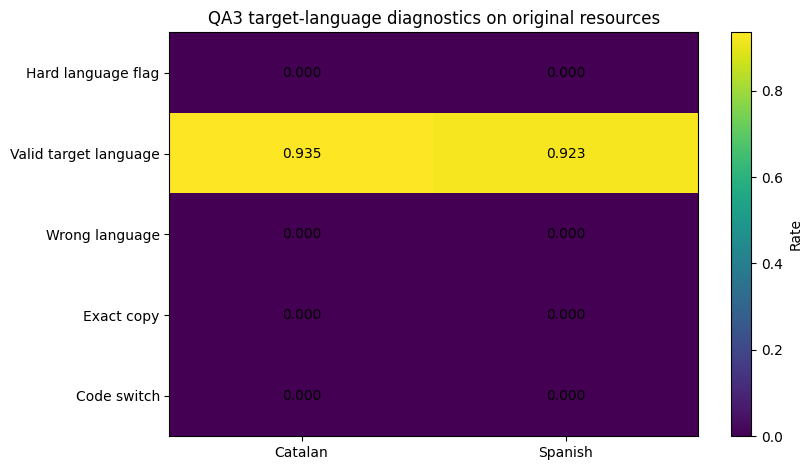

Saved QA3 outputs to /home/vramon/notebooks/WebNLG_MT_eval/QA_evaluation/results/QA3_stress_aligned


In [7]:
plot_metrics = [
    "hard_language_flag_rate",
    "valid_target_language_rate",
    "wrong_language_rate",
    "exact_source_copy_rate",
    "code_switch_rate",
]
plot = language_summary.set_index("language_label")[plot_metrics].T

fig, ax = plt.subplots(figsize=(8.5, 4.8))
image = ax.imshow(
    plot.to_numpy(dtype=float),
    aspect="auto",
    vmin=0,
    vmax=max(0.25, float(plot.max().max())),
)
ax.set_xticks(range(len(plot.columns)), plot.columns)
ax.set_yticks(
    range(len(plot.index)),
    [
        "Hard language flag",
        "Valid target language",
        "Wrong language",
        "Exact copy",
        "Code switch",
    ],
)
for row_index in range(plot.shape[0]):
    for column_index in range(plot.shape[1]):
        ax.text(
            column_index,
            row_index,
            f"{plot.iloc[row_index, column_index]:.3f}",
            ha="center",
            va="center",
        )
fig.colorbar(image, ax=ax, label="Rate")
ax.set_title("QA3 target-language diagnostics on original resources")
fig.tight_layout()
fig.savefig(
    RESULTS_DIR / "qa3_target_language_diagnostics.pdf",
    bbox_inches="tight",
)
fig.savefig(
    RESULTS_DIR / "qa3_target_language_diagnostics.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

data.to_pickle(RESULTS_DIR / "qa3_lexicalisation_metrics.pkl")
data.to_csv(
    RESULTS_DIR / "qa3_lexicalisation_metrics.csv", index=False
)
language_summary.to_csv(
    RESULTS_DIR / "qa3_original_language_summary.csv", index=False
)
variation_summary.to_csv(
    RESULTS_DIR / "qa3_variation_summary.csv", index=False
)

manual_groups = []
for language, group in data.groupby("language", sort=True):
    manual_groups.append(
        group.sample(min(60, len(group)), random_state=RANDOM_SEED)
    )
manual = pd.concat(manual_groups, ignore_index=True)
manual["manual_target_language_acceptable"] = ""
manual["manual_actual_code_switch"] = ""
manual["manual_grammar_naturalness_1_5"] = ""
manual["manual_legitimate_variation"] = ""
manual["manual_aligned_reference_interpretation"] = ""
manual["manual_notes"] = ""
manual.to_csv(
    RESULTS_DIR / "manual_qa3_audit_sheet.csv", index=False
)

metadata = {
    "metric_core_compatibility": core.CORE_COMPATIBILITY,
    "metric_core_sha256": CORE_SHA256,
    "language_training_max": LANGUAGE_TRAINING_MAX,
    "language_detector": detector_metadata,
    "entity_masking": False,
    "qa31_shared_metric_core": True,
    "qa32_shared_metric_core": True,
    "qa31_evaluation_unit": (
        "aligned RDF-to-text instance: RDF entry, lexicalisation ID, "
        "and target language"
    ),
    "qa32_evaluation_unit": (
        "aligned target lexicalisation a with aligned English "
        "lexicalisation a and a different English lexicalisation b "
        "from the same RDF entry"
    ),
    "qa32_tokenisation": (
        "whitespace tokens after normalize_space"
    ),
    "qa32_comparison_selection": (
        "first eligible different English LID after deterministic sorting"
    ),
    "qa32_advantage_defined_only_for_nonempty_same_entry_a_not_equal_b": True,
    "whole_text_language_confidence": (
        core.QA31_LANGUAGE_CONFIDENCE
    ),
    "code_switch_english_probability": (
        core.QA31_CODE_SWITCH_ENGLISH_PROBABILITY
    ),
    "code_switch_window_rate": (
        core.QA31_CODE_SWITCH_WINDOW_RATE
    ),
    "window_size": core.QA31_WINDOW_SIZE,
    "window_stride": core.QA31_WINDOW_STRIDE,
    "minimum_window_tokens": (
        core.QA31_MINIMUM_WINDOW_TOKENS
    ),
    "semantic_backend": SEMANTIC_BACKEND,
    "semantic_model": SEMANTIC_MODEL,
    "qa3_core_metrics": [
        "target_language_probability",
        "valid_target_language",
        "wrong_language_detected",
        "full_english_copy_detected",
        "code_switch_detected",
        "expansion_ratio",
        "aligned_reference_advantage",
    ],
    "moved_to_qa1": ["target_rdf_well_formed"],
    "moved_to_qa2": ["structured_predicate_retention"],
    "removed_from_core_audit": ["cross_lingual_character_overlap"],
    "lexicalisations": int(len(data)),
}
(RESULTS_DIR / "qa3_run_metadata.json").write_text(
    json.dumps(metadata, indent=2), encoding="utf-8"
)

print("Saved QA3 outputs to", RESULTS_DIR)
